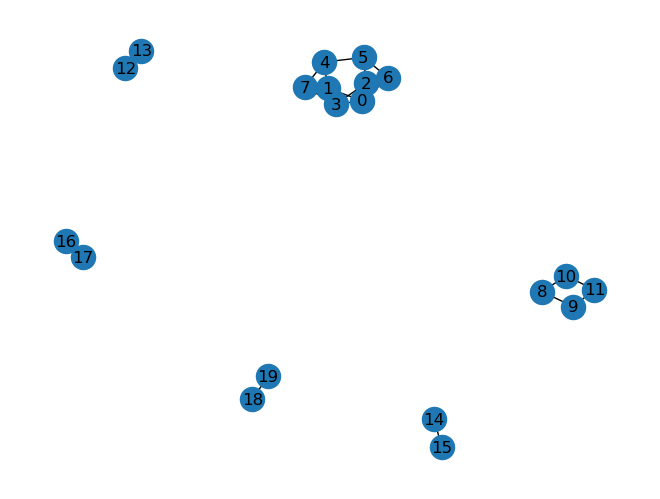

In [1]:
import networkx as nx

deg = [4,4,4,4, 3,3,3,3, 2,2,2,2, 1,1,1,1,1,1,1,1]

G = nx.havel_hakimi_graph(deg)

nx.draw(G, with_labels=True)

In [20]:
print('Number of nodes:', len(deg))
print('Number of edges:', sum(deg)/2)

Number of nodes: 12
Number of edges: 12.0


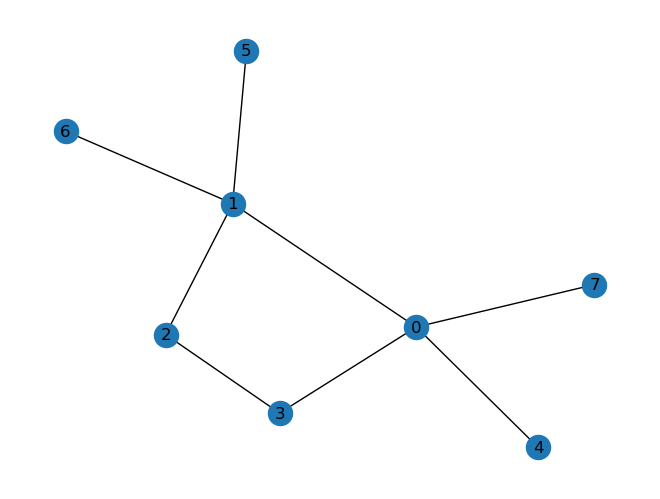

In [47]:
deg = [4,4,2,2,1,1,1,1]# [4, 4, 3, 3, 2,2,1,1, 1,1,1,1]
while True:
    G = nx.random_degree_sequence_graph(deg)
    if nx.is_connected(G):
        break
nx.draw(G, with_labels=True)
# print("Connected graph found!")

In [24]:
import random

# original degree sequence
deg = [4, 4, 3, 3, 2,2, 1,1, 1,1,1,1]
n = len(deg)

# Step 1: create empty graph
G = nx.Graph()
G.add_nodes_from(range(n))

In [27]:
# Step 2: fix some edges manually
fixed_edges = [(0,1), (1,2), (3,4), (4,5)]   # example

G.add_edges_from(fixed_edges)

In [28]:
# Step 3: compute remaining degrees
remaining_deg = deg.copy()
for u,v in fixed_edges:
    remaining_deg[u] -= 1
    remaining_deg[v] -= 1

In [29]:
# Step 4: build stub list
stubs = []
for i in range(n):
    stubs += [i]*remaining_deg[i]

In [30]:
stubs

[0, 0, 0, 1, 1, 2, 2, 3, 3, 5, 6, 7, 8, 9, 10, 11]

In [ ]:
# Step 5: shuffle and pair
random.shuffle(stubs)

while stubs:
    u = stubs.pop()
    v = stubs.pop()
    
    # avoid self-loops or duplicates
    if u == v or G.has_edge(u,v):
        continue
    
    G.add_edge(u,v)

# Now G has fixed + random structure